[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Real Dataset Loaded Successfully!
Data Cleaning and Preprocessing Completed.
Sentiment Analysis Scoring Completed.


/tmp/ipykernel_3054/2515834584.py:62: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




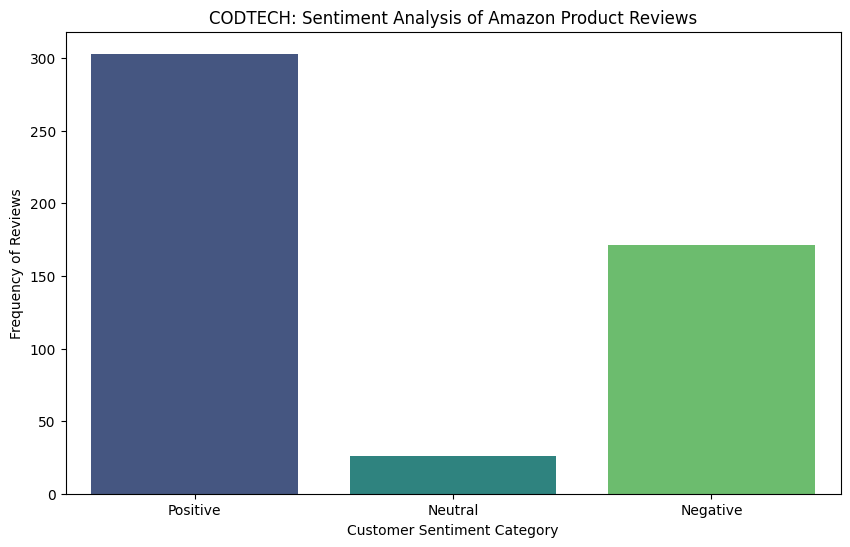

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
import re
import nltk
from nltk.corpus import stopwords

# Downloading necessary NLP resources
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# 1. Loading the real-world dataset from a remote URL
# Using a sample Amazon reviews dataset for sentiment analysis
url = 'https://raw.githubusercontent.com/pycaret/pycaret/master/datasets/amazon.csv'
df = pd.read_csv(url)

# Renaming 'reviewText' column to 'Review' for better readability
df = df[['reviewText']].rename(columns={'reviewText': 'Review'})

# Selecting the first 500 reviews to ensure faster processing
df = df.head(500)

print("Real Dataset Loaded Successfully!")

# 2. Text Cleaning Function (NLP Preprocessing)
def clean_text(text):
    # Convert text to lowercase
    text = str(text).lower()
    # Remove special characters and numbers using Regular Expressions
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenization and Stopwords removal to focus on meaningful words
    words = text.split()
    cleaned_words = [w for w in words if w not in stop_words]
    return " ".join(cleaned_words)

# Applying the cleaning function to each review
df['Cleaned_Review'] = df['Review'].apply(clean_text)
print("Data Cleaning and Preprocessing Completed.")

# 3. Sentiment Categorization Logic
def get_sentiment_category(text):
    # Analyzing the emotional tone using TextBlob
    blob = TextBlob(text)
    score = blob.sentiment.polarity

    # Categorizing based on polarity score: Positive (>0), Negative (<0), or Neutral (0)
    if score > 0:
        return 'Positive'
    elif score < 0:
        return 'Negative'
    else:
        return 'Neutral'

# Generating sentiment labels for the cleaned reviews
df['Sentiment'] = df['Cleaned_Review'].apply(get_sentiment_category)
print("Sentiment Analysis Scoring Completed.")

# 4. Visualizing the Sentiment Distribution
plt.figure(figsize=(10, 6))
# Using Seaborn to create a professional bar chart (Count Plot)
sns.countplot(x='Sentiment', data=df, palette='viridis', order=['Positive', 'Neutral', 'Negative'])

# Adding titles and labels to the chart
plt.title('CODTECH: Sentiment Analysis of Amazon Product Reviews')
plt.xlabel('Customer Sentiment Category')
plt.ylabel('Frequency of Reviews')
plt.show()